In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFTGate
import numpy as np
from qiskit_aer.backends.aer_simulator import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
import matplotlib.pyplot as plt
from scipy.linalg import expm


In [2]:
phi_max = 1
delta_phi = 2/3
#This implements the Uphi part of the trotter evolution. On site j.
# times 2 in the angle to correct RZZ.
def Uphi(qc,J2,J3,J4,j,tau, n_s):
    a1 = 2*tau * ((4*J2*phi_max**2 / 9) + (40*J4*phi_max**4 / 81) + (4*J3*phi_max**2 / 9))
    a2 = 2*tau * (4*J3*phi_max**2/9)
    a3 = 2*tau * (-2*J3*phi_max**2/9)
    a4 = 2*tau * (-8*J3*phi_max**2/9)
    a5 = 2*tau * (-4*J3*phi_max**2/9)
    a6 = 2*tau * (-4*J3*phi_max**2/9)
    qc.rzz(a1,2*j,2*j+1)
    if j!=n_s:
        #Maybe an optimal order to find.
        qc.rzz(a2,2*j+2,2*j+3)

        qc.rzz(a3,2*j,2*j+2)
        qc.rzz(a4,2*j+1,2*j+3)
        qc.rzz(a5,2*j+1,2*j+2)


        qc.rzz(a6,2*j,2*j+3)


In [3]:
def Upi(qc,J1,j,tau):
    #Again, x2 in the angle.
    qc.compose(QFTGate(2), qubits=[2*j, 2*j+1], inplace=True)
    theta = 2*J1*4*np.pi**2  / (16 * delta_phi**2)
    qc.rzz(tau*theta,2*j,2*j+1)
    qc.compose(QFTGate(2).inverse(), qubits=[2*j, 2*j+1], inplace=True)

In [4]:
def Uphi_wall(qc, n_sites,J2,J3,J4,tau):
    #Implements the Uphi on all the sites. Dont loop over sites, even and odd. 
    #Works ok, No PBCs.
    for j in range(0,n_sites-1,2):
        Uphi(qc,J2,J3,J4,j,tau,n_sites)
    for j in range(1,n_sites-1,2):
        Uphi(qc,J2,J3,J4,j,tau,n_sites)

def Uphi_wall2(qc,n_sites,J2,J3,J4,tau):
#Optimized version.
    
    nq=2*n_sites
    
    # 1. qubits next to each other
    for j in range(0, nq-1, 2):
        qc.rzz(1, j, j+1)
    for j in range(1, nq-1, 2):
        qc.rzz(1, j, j+1)
    
    # 2. qubits with 1 site between them
    for j in range(0,nq-2,3):
        qc.rzz(1, j, j+2)
    for j in range(1,nq-2,3):
        qc.rzz(1, j, j+2)
    for j in range(2,nq-2,3):
        qc.rzz(1, j, j+2)
    
    # 3. qubits with 2 sites between them
    for j in range(0, nq-3, 4):
        qc.rzz(1, j, j+3)
    for j in range(2, nq-3, 4):
        qc.rzz(1, j, j+3)
 
def Upi_wall(qc, n_sites, J1,tau):
    #Applies Upi to every sites.
    for j in range(n_sites):
        Upi(qc, J1, j ,tau)


In [9]:
def trotter_step1(qc, n_s, J1,J2,J3,J4, tau):
    #implements 1st order trotter
    Upi_wall(qc, n_s, J1, tau)    
    Uphi_wall(qc,n_s,J2,J3,J4,tau)    

def trotter_step2(qc, n_s, J1,J2,J3,J4, tau):
    #implements second order trotter step. 
    Uphi_wall(qc,n_s,J2,J3,J4,tau/2)
  # tau/2 in Uphi because second order trotter  step
    Upi_wall(qc, n_s, J1, tau)
    Uphi_wall(qc,n_s,J2,J3,J4,tau/2)
    

In [11]:
def time_evo_first_order(qc, n_s, J1, J2, J3, J4, t, dt):
    n_steps = int(round(t / dt))
    for i in range(n_steps):
        trotter_step1(qc, n_s, J1, J2, J3, J4, dt)    

def time_evo_naive(qc, n_s, J1, J2, J3, J4, t, dt):
    n_steps = int(round(t / dt))
    for i in range(n_steps):
        trotter_step2(qc, n_s, J1, J2, J3, J4, dt)

def time_evo(qc, n_s, J1, J2, J3, J4, t, dt):
    n_steps = int(round(t / dt))
    
    # Opening half-step
    Uphi_wall(qc, n_s, J2, J3, J4, dt / 2)
    
    for i in range(n_steps):
        Upi_wall(qc, n_s, J1, dt)
        
        if i < n_steps - 1:
            # Merged step  two dt/2 half-steps = dt
            Uphi_wall(qc, n_s, J2, J3, J4, dt)
        else:
            # Closing half-step
            Uphi_wall(qc, n_s, J2, J3, J4, dt / 2)


def time_evo_first_order_opti(qc, n_s, J1, J2, J3, J4, t, dt):
    n_steps = int(round(t / dt))
    for i in range(n_steps):
            Upi_wall(qc, n_s, J1, tau)    
            Uphi_wall2(qc,n_s,J2,J3,J4,tau)    

In [7]:
# this print all useful information of a quantum circuit, I got it from an IBM tutorial and updated using chatGPT
def info_qc(qc_temp):
    depth2q = 0
    qubit_busy = {}

    qubit_indices = {qubit: idx for idx, qubit in enumerate(qc_temp.qubits)}

    for inst in qc_temp.data:
        qargs = inst.qubits
        if len(qargs) == 2:
            idxs = [qubit_indices[q] for q in qargs]
            t = max(qubit_busy.get(i, 0) for i in idxs)
            for i in idxs:
                qubit_busy[i] = t + 1
            depth2q = max(depth2q, t + 1)

    print(f"""
Depth: {qc_temp.depth()}
Two-qubit depth: {depth2q}
Gate count: {len(qc_temp)}
Nonlocal gate count: {qc_temp.num_nonlocal_gates()}
Gate breakdown: {", ".join([f"{k.upper()}: {v}" for k, v in qc_temp.count_ops().items()])}
    """)


Depth: 9
Two-qubit depth: 9
Gate count: 30
Nonlocal gate count: 30
Gate breakdown: RZZ: 22, QFT: 4, QFT_DG: 4
    


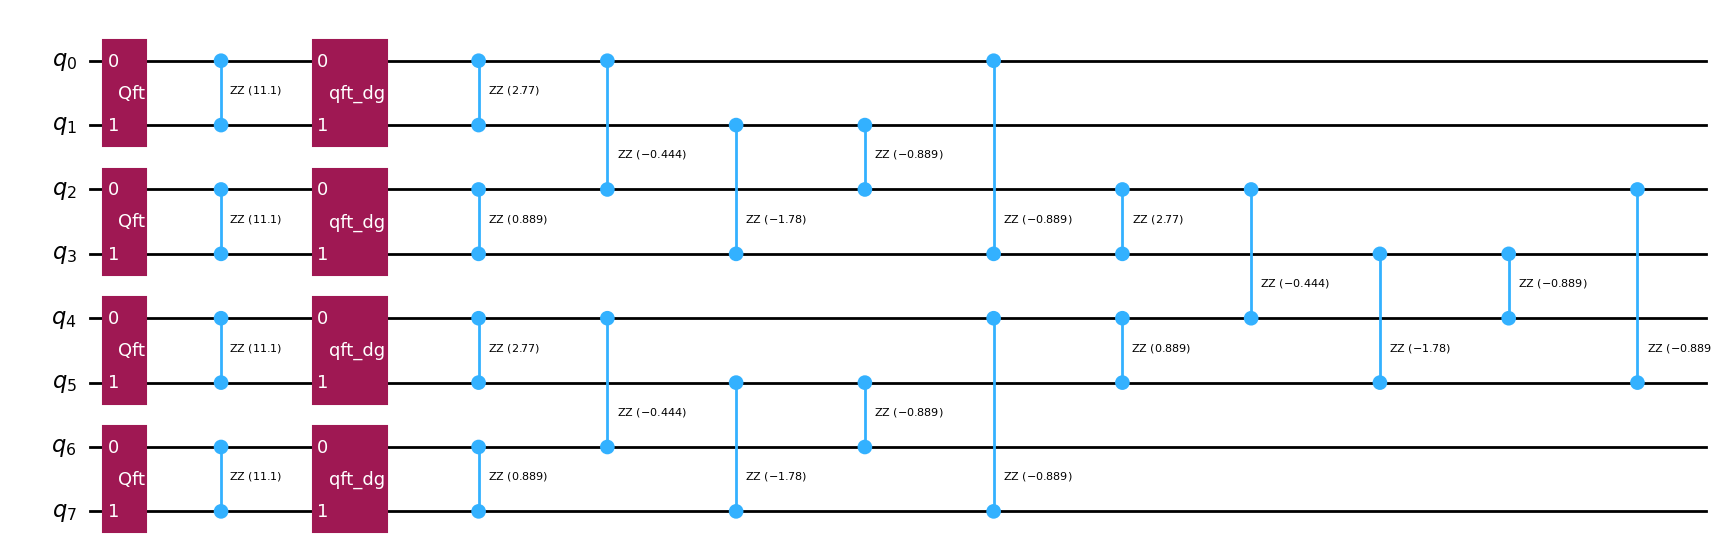

In [18]:
n_s=4
J1, J2, J3, J4, tau  = 1,1,1,1,0.1
qc1 = QuantumCircuit(8)

time_evo_first_order(qc1, 4, J1, J2, J3, J4, 1,1)

info_qc(qc1)
qc1.draw('mpl')


Depth: 8
Two-qubit depth: 8
Gate count: 28
Nonlocal gate count: 28
Gate breakdown: RZZ: 20, QFT: 4, QFT_DG: 4
    


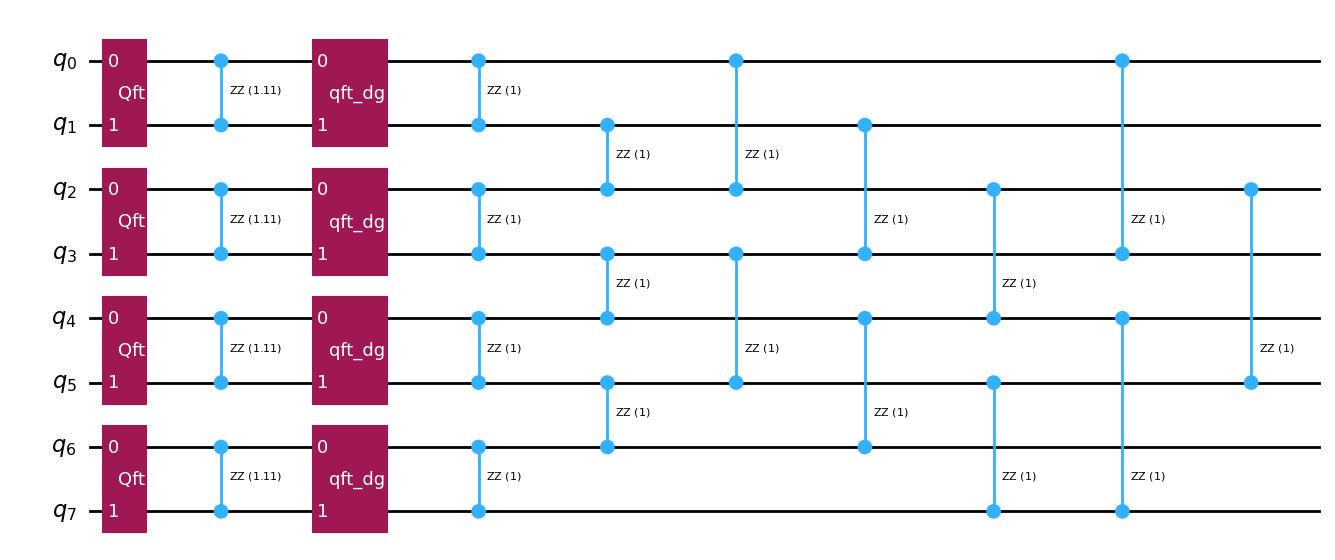

In [17]:
n_s=4
J1, J2, J3, J4, tau  = 1,1,1,1,0.1
qc2 = QuantumCircuit(8)

time_evo_first_order_opti(qc2, 4, J1, J2, J3, J4, 1,1)

info_qc(qc2)
qc2.draw('mpl')